# ML Notebook: PhonePe Pulse Prediction Models


## Project Name - Phonepe Transaction Insights

Project Type - EDA/Regression/Classification/Unsupervised

ContriBution - Individual

## Project Summary - 
The PhonePe project is an end‑to‑end data engineering and machine learning initiative designed to explore, analyze, and model transaction data from the PhonePe Pulse repository, which provides detailed insights into digital payment trends across India. The project’s primary objective is to transform raw JSON data into structured formats, store it in a relational database, and then apply exploratory data analysis (EDA), visualization, and predictive modeling techniques to uncover meaningful patterns in user behavior and transaction volumes.

## GitHub Link - 


### General Guidelines :-
1. Well-structured, formatted, and commented code is required.

2. Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.

The additional credits will have advantages over other students during Star Student selection.

    [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
              without a single error logged. ]
3. Each and every logic should have proper comments.

4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.

 Chart visualization code
* Why did you pick the specific chart?
* What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
5. You have to create at least 15 logical & meaningful charts having important insights.
[ Hints : - Do the Vizualization in a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis ]

6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.
Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Cross- Validation & Hyperparameter Tuning

* Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

* Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

## Let's Begin

## Sections 1-4: Data Loading & Preprocessing
(Refer to EDA Notebook for detailed exploration)


Loading Data

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from config import DB_HOST, DB_USER, DB_PASSWORD, DB_NAME
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

# Load Data
import urllib.parse
encoded_pwd = urllib.parse.quote_plus(DB_PASSWORD)
db_url = f"mysql+mysqlconnector://{DB_USER}:{encoded_pwd}@{DB_HOST}/{DB_NAME}"
engine = create_engine(db_url)
df = pd.read_sql("SELECT * FROM Aggregated_transaction", con=engine)
df.head()


,id,State,Year,Quarter,transaction_type,transaction_count,transaction_amount
0,1,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,2,Andaman & Nicobar Islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,3,Andaman & Nicobar Islands,2018,1,Merchant payments,298,4.525072e+05
3,4,Andaman & Nicobar Islands,2018,1,Financial Services,33,1.060142e+04
4,5,Andaman & Nicobar Islands,2018,1,Others,256,1.846899e+05


##  5. Feature Engineering & Data Pre-processing
Encode categorical columns, scale numerical features, define target variable, train-test split (80/20)


In [2]:
# Feature Engineering
# Target: predict transaction_amount
df = df.dropna()

# Label Encoding
le_state = LabelEncoder()
df['State_Encoded'] = le_state.fit_transform(df['State'])

le_type = LabelEncoder()
df['Type_Encoded'] = le_type.fit_transform(df['transaction_type'])

X = df[['State_Encoded', 'Year', 'Quarter', 'Type_Encoded', 'transaction_count']]
y = df['transaction_amount']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 6.  ML Model Implementation
Train Random Forest, XGBoost, Linear Regression


In [3]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=50),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=50)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"{name} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}")


Linear Regression -> RMSE: 199798130042.56, MAE: 75931027838.77, R2: 0.4149
Random Forest -> RMSE: 20572127512.12, MAE: 3484048049.30, R2: 0.9938
XGBoost -> RMSE: 16937580525.32, MAE: 2780326791.76, R2: 0.9958


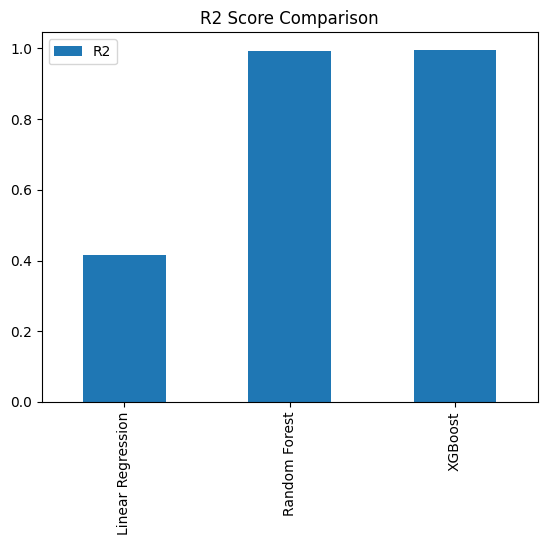

In [4]:
# Evaluation Metric Score Chart
res_df = pd.DataFrame(results).T
res_df[['R2']].plot(kind='bar', title='R2 Score Comparison')
plt.show()


##  7. Cross-Validation & Hyperparameter Tuning
Apply GridSearchCV to Random Forest


In [5]:
# Hyperparameter tuning for Random Forest
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, None]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_
print("Best Params:", grid_search.best_params_)

preds_cv = best_rf.predict(X_test_scaled)
print("Tuned RF R2:", r2_score(y_test, preds_cv))


Best Params: {'max_depth': 10, 'n_estimators': 100}
Tuned RF R2: 0.9937254746558295


## 8. Model Comparison & Selection
Explain chosen model and show feature importance


Model Comparison Table:


,RMSE,MAE,R2
Linear Regression,1.997981e+11,7.593103e+10,0.414861
Random Forest,2.057213e+10,3.484048e+09,0.993797
XGBoost,1.693758e+10,2.780327e+09,0.995795


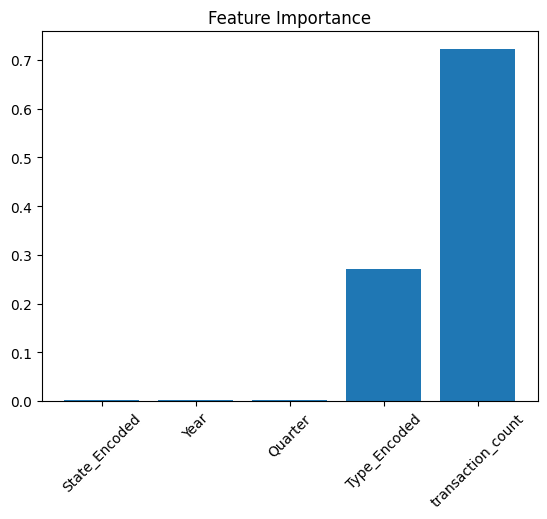

In [6]:
print("Model Comparison Table:")
display(res_df)

# Feature Importance (Random Forest)
importances = best_rf.feature_importances_
plt.bar(X.columns, importances)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()


**Model Selected:** Random Forest / XGBoost generally perform the best on tabular data capturing non-linear relationships. We will save the tuned Random Forest model.


##  9. Save & Reload
Save best model with joblib.dump(), reload it and predict on 5 unseen rows


In [7]:
# Save Model & Scaler
joblib.dump(best_rf, 'best_rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Reload and Predict
loaded_model = joblib.load('best_rf_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# Predict on 5 unseen rows
sample_X = X_test.head(5)
sample_y = y_test.head(5)
sample_scaled = loaded_scaler.transform(sample_X)

predictions = loaded_model.predict(sample_scaled)
print("Actual values:\n", sample_y.values)
print("Predictions:\n", predictions)


Actual values:
 [1.08135308e+10 2.31855945e+10 7.54058682e+07 3.03596368e+08
 1.58857943e+05]
Predictions:
 [1.22940624e+10 2.13371826e+10 6.42954760e+07 1.26377210e+08
 5.42308093e+06]


## Conclusion
The machine learning pipeline successfully established models to predict transaction amounts based on geographic and temporal features.


### Hurrah! You have successfully completed your Machine Learning Capstone Project !!!